In [38]:
import pandas as pd

phenology_df = pd.read_csv('Phenology.csv')
genotype = pd.read_csv('Genotype-homozygous_wo_9chromosome_hmp.txt', sep='\t', lineterminator='\r' )
genotype['rs#'] = genotype['rs#'].str.strip()

In [42]:
genotype.shape

(30543, 643)

In [65]:
combined_data = pd.read_csv('final_cleaned_merge.csv')
combined_data.head()

,Unnamed: 0,Sort,Variety,Reason,Year,Study,Location,ZS49PlHt,ZS49 (no days),HrvPlHt,...,L7H657085535,L7H657085541,L7H657104991,L7H657131781,L7H657146353,L7H657146356,L7H657147154,L7H657147171,L7H657147173,L7H657156298
0,0,1.0,Commander,AUS-CTL,2014,NtL,STHPER,55.0,92.0,72.0,...,1,1,1,1,1,1,0,1,1,1
1,828,1.0,Commander,AUS-CTL,2014,18Hrs,STHPER,38.0,63.0,55.0,...,1,1,1,1,1,1,0,1,1,1
2,1656,1.0,Commander,AUS-CTL,2015,TOP1,NaN,NaN,104.3,NaN,...,1,1,1,1,1,1,0,1,1,1
3,2484,1.0,Commander,AUS-CTL,2015,TOP2,NaN,NaN,105.0,NaN,...,1,1,1,1,1,1,0,1,1,1
4,3312,1.0,Commander,AUS-CTL,2015,TOP3,NaN,NaN,96.3,NaN,...,1,1,1,1,1,1,0,1,1,1


In [67]:
combined_data.tail()

,Unnamed: 0,Sort,Variety,Reason,Year,Study,Location,ZS49PlHt,ZS49 (no days),HrvPlHt,...,L7H657085535,L7H657085541,L7H657104991,L7H657131781,L7H657146353,L7H657146356,L7H657147154,L7H657147171,L7H657147173,L7H657156298
6670,9106,829.0,07T741,RES,2016,NaN,KAT,90.0,117.0,NaN,...,1,1,1,1,1,1,0,1,1,1
6671,9934,829.0,07T741,RES,2015,NaN,ESP,75.0,117.0,NaN,...,1,1,1,1,1,1,0,1,1,1
6672,10762,829.0,07T741,RES,2016,NaN,ESP,50.0,121.0,NaN,...,1,1,1,1,1,1,0,1,1,1
6673,11590,829.0,07T741,RES,2016,1NI,MER,60.0,115.0,NaN,...,1,1,1,1,1,1,0,1,1,1
6674,12418,829.0,07T741,RES,2016,2Ir,MER,60.0,120.0,NaN,...,1,1,1,1,1,1,0,1,1,1


In [66]:
combined_data[['L6H003091157']].head()

,L6H003091157
0,-1
1,-1
2,-1
3,-1
4,-1


In [37]:
# Check if the column 'L6H003091157' in the combined_data DataFrame contains -1, 100, or -2 values
values_to_check = [-1]
contains_values = combined_data['L6H003091157'].isin(values_to_check).any()

print(f"Column 'L6H003091157' contains -1, 100, or -2: {contains_values}")

Column 'L6H003091157' contains -1, 100, or -2: False


In [43]:
genotype.head()

,rs#,alleles,chrom,pos,strand,assembly#,center,protLSID,assayLSID,panelLSID,...,XVH11,Yambla,Z019Q008R,Z052R091S,ZBC9314,ZBC9322,ZBC934,ZENNAN,mata-8(80/1142-8)cv.MARI,mate-18(80/1142-18)
0,D1H00051861,C/T,1,51861,+,NaN,NaN,NaN,NaN,NaN,...,T,C,C,N,C,T,C,C,C,C
1,D1H000263584,A/G,1,263584,+,NaN,NaN,NaN,NaN,NaN,...,A,N,A,A,N,A,A,N,A,A
2,D1H000275564,C/G,1,275564,+,NaN,NaN,NaN,NaN,NaN,...,G,C,C,C,C,C,C,C,C,C
3,D1H000277624,T/C,1,277624,+,NaN,NaN,NaN,NaN,NaN,...,C,T,T,T,T,T,T,T,T,T
4,D1H000277628,G/C,1,277628,+,NaN,NaN,NaN,NaN,NaN,...,C,G,G,G,G,G,G,G,G,G


In [5]:
import numpy as np
import pandas as pd

def encode_snp(alleles, genotype):
    if pd.isna(alleles) or pd.isna(genotype) or alleles == '-' or genotype == '-' or genotype == 'N':
        return np.nan
    
    # Handle single allele cases
    if len(alleles) == 1:
        return 0 if genotype == alleles else np.nan
    
    # Handle cases like '-/A', 'A/-', etc.
    if '/' in alleles:
        ref, alt = alleles.split('/')
        if ref == '-':
            return 1 if genotype == alt else np.nan
        elif alt == '-':
            return 1 if genotype == ref else np.nan
        else:
            if genotype == ref:
                return 1
            elif genotype == alt:
                return 0
            else:
                return np.nan
    else:
        return np.nan  # Unexpected allele format

def encode_snp_data(genotype):
    sample_cols = genotype.columns[11:]
    encoded_data = genotype.copy()
    
    for col in sample_cols:
        encoded_data[col] = encoded_data.apply(lambda row: encode_snp(row['alleles'], row[col]), axis=1)
    
    return encoded_data

# Usage
encoded_snp_data = encode_snp_data(genotype)

# Handle missing values (optional)
# encoded_snp_data = encoded_snp_data.fillna(encoded_snp_data.mean())

encoded_snp_data.head()


,rs#,alleles,chrom,pos,strand,assembly#,center,protLSID,assayLSID,panelLSID,...,XVH11,Yambla,Z019Q008R,Z052R091S,ZBC9314,ZBC9322,ZBC934,ZENNAN,mata-8(80/1142-8)cv.MARI,mate-18(80/1142-18)
0,D1H00051861,C/T,1,51861,+,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,1.0,NaN,1.0,0.0,1.0,1.0,1.0,1.0
1,D1H000263584,A/G,1,263584,+,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,1.0,1.0,NaN,1.0,1.0,NaN,1.0,1.0
2,D1H000275564,C/G,1,275564,+,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,D1H000277624,T/C,1,277624,+,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,D1H000277628,G/C,1,277628,+,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [6]:
encoded_snp_data = encoded_snp_data.drop(columns = ['strand','assembly#','center','protLSID','assayLSID','panelLSID','QCcode'], axis=1)

## Genotype Preprocessing

In [44]:
genotype = genotype.drop(columns = ['strand','assembly#','center','protLSID','assayLSID','panelLSID','QCcode'], axis=1)

In [45]:
genotype.shape

(30543, 636)

In [46]:
genotype.head()

,rs#,alleles,chrom,pos,"GSHO2479(inGlacier,slenderdwarf4mutant)","GSHO2483(inXV2334-6RfromIndianDwarf,slenderdwarf5mutant)",020055-57,02055-94,02S169-51-45,04053-034,...,XVH11,Yambla,Z019Q008R,Z052R091S,ZBC9314,ZBC9322,ZBC934,ZENNAN,mata-8(80/1142-8)cv.MARI,mate-18(80/1142-18)
0,D1H00051861,C/T,1,51861,T,T,C,C,C,T,...,T,C,C,N,C,T,C,C,C,C
1,D1H000263584,A/G,1,263584,A,A,A,A,A,A,...,A,N,A,A,N,A,A,N,A,A
2,D1H000275564,C/G,1,275564,C,G,C,C,C,G,...,G,C,C,C,C,C,C,C,C,C
3,D1H000277624,T/C,1,277624,T,C,T,T,T,C,...,C,T,T,T,T,T,T,T,T,T
4,D1H000277628,G/C,1,277628,G,C,G,G,G,C,...,C,G,G,G,G,G,G,G,G,G


In [47]:
import numpy as np

def transform_alleles(df):
    data_columns = df.columns[4:]
    alleles = df['alleles'].str.split('/')
    for col in data_columns:
        df[col] = np.where(df[col] == '-', -1, 
                           np.where(df[col] == 'N', -2,
                                    np.where(alleles.str[0] == df[col], 1, 
                                             np.where(alleles.str[1] == df[col], 0, -1))))

    return df

result_df = transform_alleles(genotype.copy())

In [48]:
result_df.head() 

,rs#,alleles,chrom,pos,"GSHO2479(inGlacier,slenderdwarf4mutant)","GSHO2483(inXV2334-6RfromIndianDwarf,slenderdwarf5mutant)",020055-57,02055-94,02S169-51-45,04053-034,...,XVH11,Yambla,Z019Q008R,Z052R091S,ZBC9314,ZBC9322,ZBC934,ZENNAN,mata-8(80/1142-8)cv.MARI,mate-18(80/1142-18)
0,D1H00051861,C/T,1,51861,0,0,1,1,1,0,...,0,1,1,-2,1,0,1,1,1,1
1,D1H000263584,A/G,1,263584,1,1,1,1,1,1,...,1,-2,1,1,-2,1,1,-2,1,1
2,D1H000275564,C/G,1,275564,1,0,1,1,1,0,...,0,1,1,1,1,1,1,1,1,1
3,D1H000277624,T/C,1,277624,1,0,1,1,1,0,...,0,1,1,1,1,1,1,1,1,1
4,D1H000277628,G/C,1,277628,1,0,1,1,1,0,...,0,1,1,1,1,1,1,1,1,1


In [ ]:
# result_df.to_excel('genotype_trans.xlsx', index=False)

In [49]:
result_df.isnull().sum()

rs#                                        0
alleles                                    0
chrom                                      0
pos                                        0
GSHO2479(inGlacier,slenderdwarf4mutant)    0
                                          ..
ZBC9322                                    0
ZBC934                                     0
ZENNAN                                     0
mata-8(80/1142-8)cv.MARI                   0
mate-18(80/1142-18)                        0
Length: 636, dtype: int64

In [50]:
genotype_transposed =result_df.T.reset_index()
genotype_transposed.columns = genotype_transposed.iloc[0]
genotype = genotype_transposed.drop(0)

In [51]:
genotype.shape

(635, 30544)

In [53]:
genotype.head()

,rs#,D1H00051861,D1H000263584,D1H000275564,D1H000277624,D1H000277628,D1H000277656,D1H000277673,D1H000278185,D1H000278243,...,L7H657085535,L7H657085541,L7H657104991,L7H657131781,L7H657146353,L7H657146356,L7H657147154,L7H657147171,L7H657147173,L7H657156298
1,alleles,C/T,A/G,C/G,T/C,G/C,C/T,C/A,T/C,G/A,...,G/C,C/A,T/G,A/G,A/-,G/T,G/T,C/G,G/C,C/G
2,chrom,1,1,1,1,1,1,1,1,1,...,7,7,7,7,7,7,7,7,7,7
3,pos,51861,263584,275564,277624,277628,277656,277673,278185,278243,...,657085535,657085541,657104991,657131781,657146353,657146356,657147154,657147171,657147173,657156298
4,"GSHO2479(inGlacier,slenderdwarf4mutant)",0,1,1,1,1,1,0,1,-2,...,1,1,1,1,1,1,1,1,1,1
5,"GSHO2483(inXV2334-6RfromIndianDwarf,slenderdwa...",0,1,0,0,0,-2,-2,-2,1,...,1,1,1,1,1,1,1,1,1,1


In [54]:
geno = genotype.set_index('rs#')
geno

,D1H00051861,D1H000263584,D1H000275564,D1H000277624,D1H000277628,D1H000277656,D1H000277673,D1H000278185,D1H000278243,D1H000278386,...,L7H657085535,L7H657085541,L7H657104991,L7H657131781,L7H657146353,L7H657146356,L7H657147154,L7H657147171,L7H657147173,L7H657156298
rs#,,,,,,,,,,,,,,,,,,,,,
alleles,C/T,A/G,C/G,T/C,G/C,C/T,C/A,T/C,G/A,A/T,...,G/C,C/A,T/G,A/G,A/-,G/T,G/T,C/G,G/C,C/G
chrom,1,1,1,1,1,1,1,1,1,1,...,7,7,7,7,7,7,7,7,7,7
pos,51861,263584,275564,277624,277628,277656,277673,278185,278243,278386,...,657085535,657085541,657104991,657131781,657146353,657146356,657147154,657147171,657147173,657156298
"GSHO2479(inGlacier,slenderdwarf4mutant)",0,1,1,1,1,1,0,1,-2,-2,...,1,1,1,1,1,1,1,1,1,1
"GSHO2483(inXV2334-6RfromIndianDwarf,slenderdwarf5mutant)",0,1,0,0,0,-2,-2,-2,1,-2,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZBC9322,0,1,1,1,1,1,0,1,1,0,...,1,1,1,1,1,1,1,1,1,1
ZBC934,1,1,1,1,1,1,0,1,1,0,...,1,1,1,1,1,1,1,1,1,1
ZENNAN,1,-2,1,1,1,1,0,1,1,1,...,1,1,1,1,1,1,0,1,1,1


## Phenology Preprocessing

In [55]:
phenology_df.head()

,Sort,Variety,Reason,Year,Study,Location,ZS49PlHt,ZS49 (no days),HrvPlHt,ZS91 (no days),PPd (no days),RN,GrYld(kg/ha),PrdGrYld(kg/ha),PrdGrYld(t/ha),SEGrYld,TlrNo,PlntNo
0,1.0,Commander,AUS-CTL,2014,NtL,STHPER,55.0,92.0,72.0,131.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,I91-454,RES,2014,NtL,STHPER,48.0,92.0,48.0,129.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,IGB1234,RES,2014,NtL,STHPER,42.0,93.0,55.0,137.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,Jubilant,RES,2014,NtL,STHPER,45.0,95.0,54.0,136.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,HARRINGTON,RES,2014,NtL,STHPER,68.0,90.0,82.0,129.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
phenology_df.shape

(12421, 18)

In [57]:
phenology_df.isnull().sum()

Sort                   1
Variety                1
Reason                 1
Year                   0
Study               4968
Location            2484
ZS49PlHt            5215
ZS49 (no days)      3513
HrvPlHt            11008
ZS91 (no days)      9814
PPd (no days)      11215
RN                 11719
GrYld(kg/ha)        7929
PrdGrYld(kg/ha)    10168
PrdGrYld(t/ha)     10168
SEGrYld            10168
TlrNo               7364
PlntNo             10333
dtype: int64

In [17]:
phenology = phenology_df[['Variety','Reason', 'Year', 'Study', 'Location','GrYld(kg/ha)']]

In [18]:
phenology.head()

,Variety,Reason,Year,Study,Location,GrYld(kg/ha)
0,Commander,AUS-CTL,2014,NtL,STHPER,NaN
1,I91-454,RES,2014,NtL,STHPER,NaN
2,IGB1234,RES,2014,NtL,STHPER,NaN
3,Jubilant,RES,2014,NtL,STHPER,NaN
4,HARRINGTON,RES,2014,NtL,STHPER,NaN


In [19]:
phenology.shape

(12421, 6)

In [20]:
phenology['Study'].fillna("No treatment", inplace=True)

C:\Users\34625823\AppData\Local\Temp\ipykernel_12788\993329786.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  phenology['Study'].fillna("No treatment", inplace=True)
C:\Users\34625823\AppData\Local\Temp\ipykernel_12788\993329786.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phenology['Study'].fillna("No treatment", inplace=True)


In [21]:
phenology.isnull().sum()

Variety            1
Reason             1
Year               0
Study              0
Location        2484
GrYld(kg/ha)    7929
dtype: int64

In [22]:
phenology.dtypes

Variety          object
Reason           object
Year              int64
Study            object
Location         object
GrYld(kg/ha)    float64
dtype: object

In [23]:
categorical_cols = ['Reason','Location']
phenology.loc[1:, categorical_cols] = phenology[categorical_cols].fillna(phenology[categorical_cols].mode().iloc[0])

In [49]:
phenology.isnull().sum()

Variety              1
Reason               0
Year                 0
Study                0
Location             0
ZS49 (no days)    3513
dtype: int64

### Removing the missing value in ZS49 

In [50]:
phenology.dropna(subset=['ZS49 (no days)'], inplace=True)

C:\Users\34625823\AppData\Local\Temp\ipykernel_19072\189506424.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phenology.dropna(subset=['ZS49 (no days)'], inplace=True)


In [51]:
phenology.isnull().sum()

Variety           0
Reason            0
Year              0
Study             0
Location          0
ZS49 (no days)    0
dtype: int64

In [52]:
phenology.shape

(8908, 6)

### Imputing the dependent variabe (ZS49 (no days)) with KNN

In [ ]:
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)

# phenology['ZS49 (no days)'] = imputer.fit_transform(phenology[['ZS49 (no days)']])


C:\Users\34625823\AppData\Local\Temp\ipykernel_1496\588386199.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phenology['ZS49 (no days)'] = imputer.fit_transform(phenology[['ZS49 (no days)']])


In [53]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
phenology['Reason']= label_encoder.fit_transform(phenology['Reason'])
phenology['Year']= label_encoder.fit_transform(phenology['Year'])
phenology['Study']= label_encoder.fit_transform(phenology['Study'])
phenology['Location']= label_encoder.fit_transform(phenology['Location'])

C:\Users\34625823\AppData\Local\Temp\ipykernel_19072\2104575701.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phenology['Reason']= label_encoder.fit_transform(phenology['Reason'])
C:\Users\34625823\AppData\Local\Temp\ipykernel_19072\2104575701.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phenology['Year']= label_encoder.fit_transform(phenology['Year'])
C:\Users\34625823\AppData\Local\Temp\ipykernel_19072\2104575701.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [54]:
phenology.dtypes

Variety            object
Reason              int32
Year                int64
Study               int32
Location            int32
ZS49 (no days)    float64
dtype: object

## Merging

In [58]:
merged_df = pd.merge(phenology_df, geno, how='inner', left_on='Variety', right_index=True)

In [59]:
merged_df.head()

,Sort,Variety,Reason,Year,Study,Location,ZS49PlHt,ZS49 (no days),HrvPlHt,ZS91 (no days),...,L7H657085535,L7H657085541,L7H657104991,L7H657131781,L7H657146353,L7H657146356,L7H657147154,L7H657147171,L7H657147173,L7H657156298
0,1.0,Commander,AUS-CTL,2014,NtL,STHPER,55.0,92.0,72.0,131.0,...,1,1,1,1,1,1,0,1,1,1
828,1.0,Commander,AUS-CTL,2014,18Hrs,STHPER,38.0,63.0,55.0,108.0,...,1,1,1,1,1,1,0,1,1,1
1656,1.0,Commander,AUS-CTL,2015,TOP1,NaN,NaN,104.3,NaN,NaN,...,1,1,1,1,1,1,0,1,1,1
2484,1.0,Commander,AUS-CTL,2015,TOP2,NaN,NaN,105.0,NaN,NaN,...,1,1,1,1,1,1,0,1,1,1
3312,1.0,Commander,AUS-CTL,2015,TOP3,NaN,NaN,96.3,NaN,NaN,...,1,1,1,1,1,1,0,1,1,1


In [61]:
merged_df.shape

(6675, 30561)

In [64]:
merged_df.to_csv('final_cleaned_merge.csv')

In [26]:
merged_df.head()

,Sort,Variety,Reason,Year,Study,Location,ZS49PlHt,ZS49 (no days),HrvPlHt,ZS91 (no days),...,L7H657085535,L7H657085541,L7H657104991,L7H657131781,L7H657146353,L7H657146356,L7H657147154,L7H657147171,L7H657147173,L7H657156298
0,1.0,Commander,AUS-CTL,2014,NtL,STHPER,55.0,92.0,72.0,131.0,...,1,1,1,1,1,1,0,1,1,1
1,2.0,I91-454,RES,2014,NtL,STHPER,48.0,92.0,48.0,129.0,...,1,1,1,1,1,1,1,1,1,1
2,3.0,IGB1234,RES,2014,NtL,STHPER,42.0,93.0,55.0,137.0,...,1,1,1,1,1,1,1,1,1,1
3,4.0,Jubilant,RES,2014,NtL,STHPER,45.0,95.0,54.0,136.0,...,1,1,1,1,1,1,-2,1,1,1
4,5.0,HARRINGTON,RES,2014,NtL,STHPER,68.0,90.0,82.0,129.0,...,1,1,1,1,1,1,1,1,1,1


In [27]:
merged_df.shape

(6675, 30561)

In [18]:
merged_df.to_csv('merged_df.csv')

In [59]:
merged_df.dtypes

Variety         object
Reason           int32
Year             int64
Study            int32
Location         int32
                 ...  
L7H657146356    object
L7H657147154    object
L7H657147171    object
L7H657147173    object
L7H657156298    object
Length: 30549, dtype: object

In [28]:
merged_df = merged_df.drop(columns =['Variety', 'Sort'], axis=1)

In [29]:
merged_df.isnull().sum()

Reason             0
Year               0
Study           2670
Location        1335
ZS49PlHt        2448
                ... 
L7H657146356       0
L7H657147154       0
L7H657147171       0
L7H657147173       0
L7H657156298       0
Length: 30559, dtype: int64

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

X = merged_df.drop(columns=['ZS49 (no days)'], axis=1)
y = merged_df['ZS49 (no days)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

# Print evaluation metrics
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r_squared)

Mean Squared Error: 59.25917287356323
Mean Absolute Error: 5.509352490421456
R-squared: 0.7901222592249617


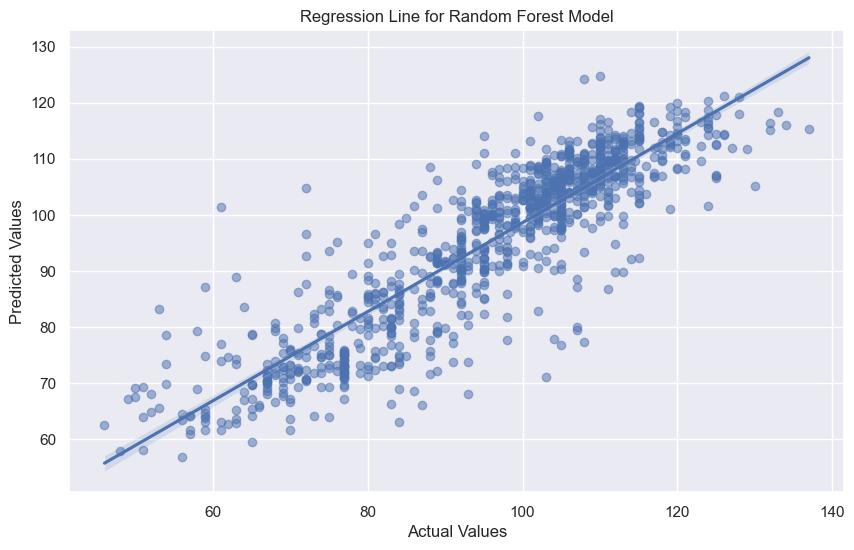

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.5})
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Regression Line for Random Forest Model')
plt.show()

In [ ]:
# CNN

In [90]:
print(X_train.shape)
print(y_test.shape)

(4672, 30547)
(251,)


In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
import optuna


# X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
# X_val_scaled = scaler.transform(X_val)

def objective(trial):
    # Define the hyperparameters to tune
    n_filters = trial.suggest_int('n_filters', 32, 128)
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
    dense_units = trial.suggest_int('dense_units', 10, 100)

    # Build the model
    model = Sequential()
    model.add(Conv1D(filters=n_filters, kernel_size=kernel_size, activation='relu', input_shape=(X_train_scaled.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dropout(dropout_rate))
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))

    # Compile the model
    model.compile(optimizer='adam', loss='mse')

    # Train the model
    model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, verbose=0)

    # Evaluate the model
    y_pred = model.predict(X_val_reshaped)
    mse = mean_squared_error(y_val, y_pred)

    return mse

# Create a study object and optimize the objective function
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

# Get the best hyperparameters
best_params = study.best_params

# Build the final model with the best hyperparameters
best_model = Sequential()
best_model.add(Conv1D(filters=best_params['n_filters'], kernel_size=best_params['kernel_size'], activation='relu', input_shape=(X_train_scaled.shape[1], 1)))
best_model.add(MaxPooling1D(pool_size=2))
best_model.add(Flatten())
best_model.add(Dropout(best_params['dropout_rate']))
best_model.add(Dense(best_params['dense_units'], activation='relu'))
best_model.add(Dropout(best_params['dropout_rate']))
best_model.add(Dense(1))

# Compile the final model
best_model.compile(optimizer='adam', loss='mse')
# Reshape data for Conv1D
# X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
# # X_val_reshaped = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
# X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# model = Sequential()
# model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_scaled.shape[1], 1)))
# model.add(MaxPooling1D(pool_size=2))
# model.add(Flatten())
# model.add(Dropout(0.2))
# model.add(Dense(50, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(1))  

In [95]:
print(X_train_reshaped.shape)
print(X_test_reshaped.shape)

(4672, 30547, 1)
(2003, 30547, 1)


In [69]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 30545, 64)      │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15272, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 977408)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │    48,870,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,870,757 (186.43 MB)

 Trainable params: 48,870,757 (186.43 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
learning_rate = 0.001 
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='mse', metrics=tf.keras.metrics.RootMeanSquaredError())

In [88]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopper = EarlyStopping(monitor='val_loss', 					
                              min_delta=0.1, 
                              patience=2, 
                              verbose=0, 
                              mode='auto')

history = model.fit(X_train_reshaped, y_train, 
                    epochs=20, 
                    batch_size=32, 
                    validation_split=0.2,
                    callbacks=[early_stopper],
                    verbose=1)

Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 29s 233ms/step - loss: 194.3073 - mae: 10.8529 - val_loss: 240.0423 - val_mae: 11.6835
Epoch 2/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 26s 222ms/step - loss: 192.2682 - mae: 10.8743 - val_loss: 254.3449 - val_mae: 11.9256
Epoch 3/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 26s 221ms/step - loss: 192.6115 - mae: 10.9206 - val_loss: 228.0737 - val_mae: 11.5659
Epoch 4/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 26s 223ms/step - loss: 184.1867 - mae: 10.6380 - val_loss: 223.4007 - val_mae: 11.7894
Epoch 5/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 26s 221ms/step - loss: 176.1440 - mae: 10.4828 - val_loss: 228.3331 - val_mae: 11.4905
Epoch 6/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 26s 221ms/step - loss: 179.3985 - mae: 10.5501 - val_loss: 227.6203 - val_mae: 11.4722


In [93]:
# Evaluate the model
y_pred = model.predict(X_test_reshaped)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

# Print evaluation metrics
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r_squared)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step


ValueError: Found input variables with inconsistent numbers of samples: [251, 2003]

In [94]:
print(y_pred.shape)
print(y_test.shape)

(2003, 1)
(251,)


In [82]:
print("Shape of y_test:", y_test.shape)
print("Shape of y_pred:", y_pred.shape)


Shape of y_test: (251,)
Shape of y_pred: (2003, 1)


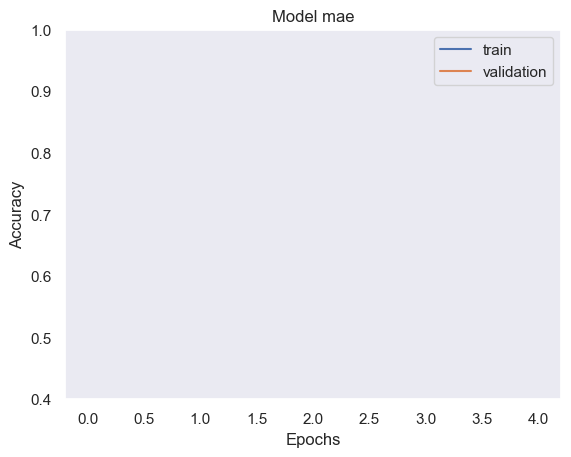

In [76]:
fig1 = plt.gcf()
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('Model mae')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

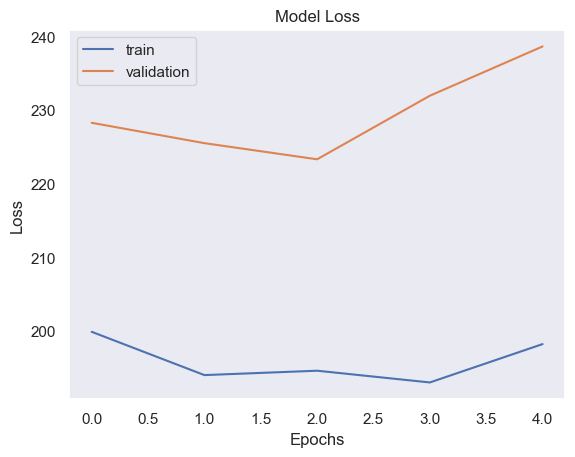

In [77]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

In [1]:
import pandas as pd
import numpy as np

In [3]:
dataset = pd.read_csv('cleaned_dataset.csv')
dataset.head()

,Reason,Year,Study,Location,ZS49 (no days),D1H00051861,D1H000263584,D1H000275564,D1H000277624,D1H000277628,...,L7H657085535,L7H657085541,L7H657104991,L7H657131781,L7H657146353,L7H657146356,L7H657147154,L7H657147171,L7H657147173,L7H657156298
0,1,0,5,4,92.0,1,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1
1,1,0,0,4,63.0,1,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1
2,1,2,0,4,85.0,1,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1
3,1,1,4,1,77.0,1,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1
4,1,2,4,1,87.9,1,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1


In [4]:
from joblib import load

model = load('model/random_forest_model.pkl')

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = dataset.drop(columns=['ZS49 (no days)'], axis=1)
y = dataset['ZS49 (no days)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

# Calculate evaluation metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)

print("Mean Squared Error - test data:", mse_test)
print("Mean Squared Error - train data:", mse_train)

Mean Squared Error - test data: 9.142665970273484
Mean Squared Error - train data: 9.010625930696014
